<a href="https://colab.research.google.com/github/minecode0606/Medical_Cost_Personal_Data_Analytics/blob/master/Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 데이터 시각화

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
def load_insurance_data():
    try:
        dataset = pd.read_csv('/content/insurance.csv')
    except:
        dataset = pd.read_csv('./dataset/insurance.csv')
    return dataset

In [ ]:
insurance_df = load_insurance_data()

In [ ]:
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
insurance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
insurance_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


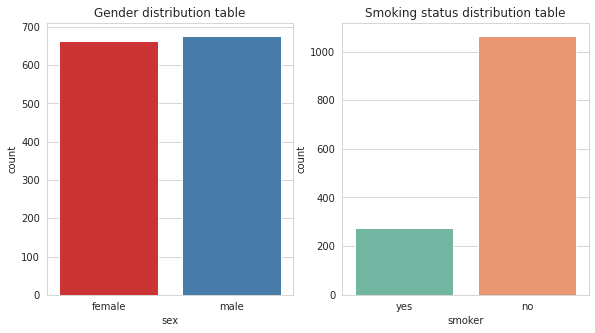

In [ ]:
%matplotlib inline
sns.set_style("whitegrid")

smoke_sex_fig = plt.figure(figsize=(15,5))
sex_countplot_field = smoke_sex_fig.add_subplot(1,3,1)
smoke_countplot_field = smoke_sex_fig.add_subplot(1,3,2)

sns.countplot(x = 'sex',palette='Set1', data=insurance_df, ax=sex_countplot_field)
sns.countplot(x = 'smoker', palette='Set2', data=insurance_df, ax=smoke_countplot_field)

sex_countplot_field.set_title('Gender distribution table')
smoke_countplot_field.set_title('Smoking status distribution table')

plt.show()

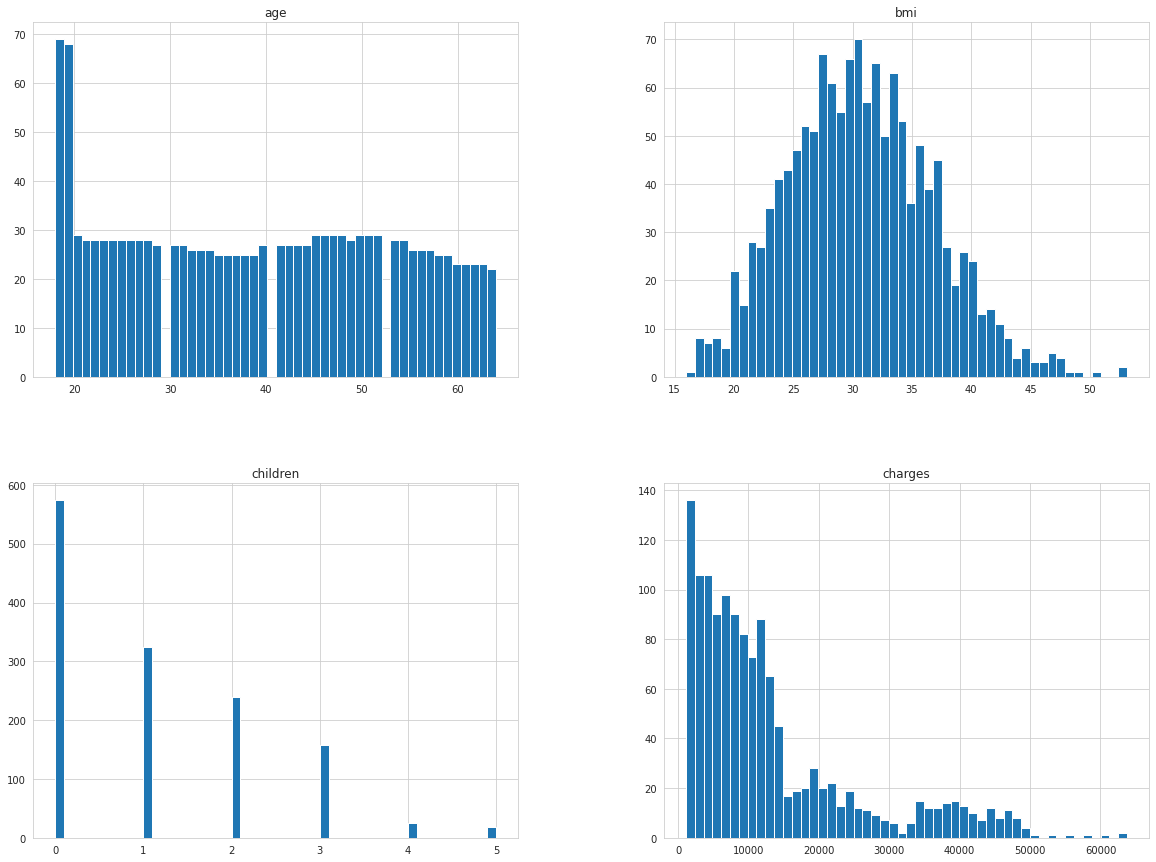

In [ ]:
insurance_df.hist(bins=50, figsize=(20,15))
plt.show()

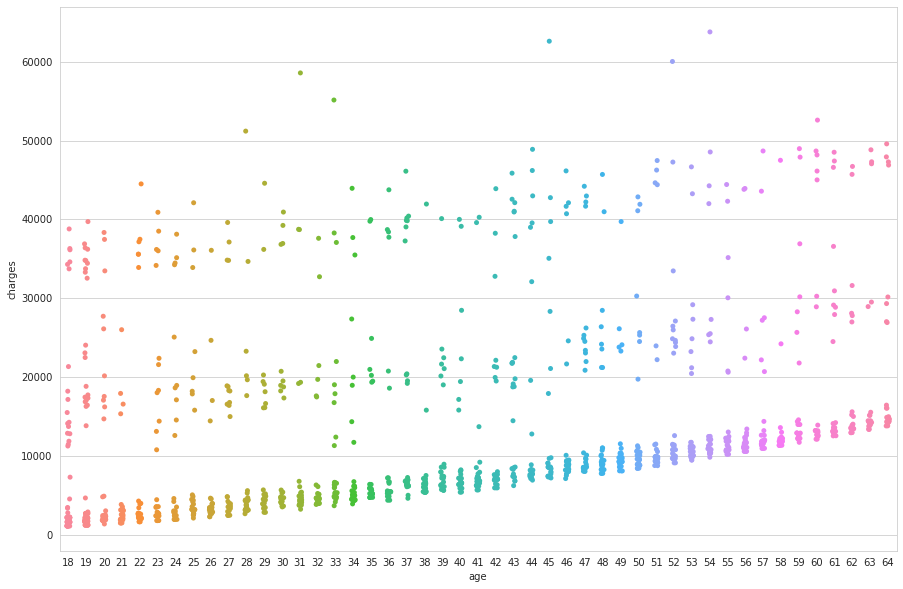

In [ ]:
age_bmi_Scatterplot = plt.figure(figsize=(15, 10))

age_bmi_swarmplot_field = age_bmi_Scatterplot.add_subplot(1,1,1)

sns.set_style('darkgrid')

sns.stripplot(x = 'age', y='charges', data=insurance_df, ax=age_bmi_swarmplot_field)
plt.show()

/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 58.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 54.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 34.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/categorical.py:1296: UserWarning: 42.9% of the points cannot be placed; y

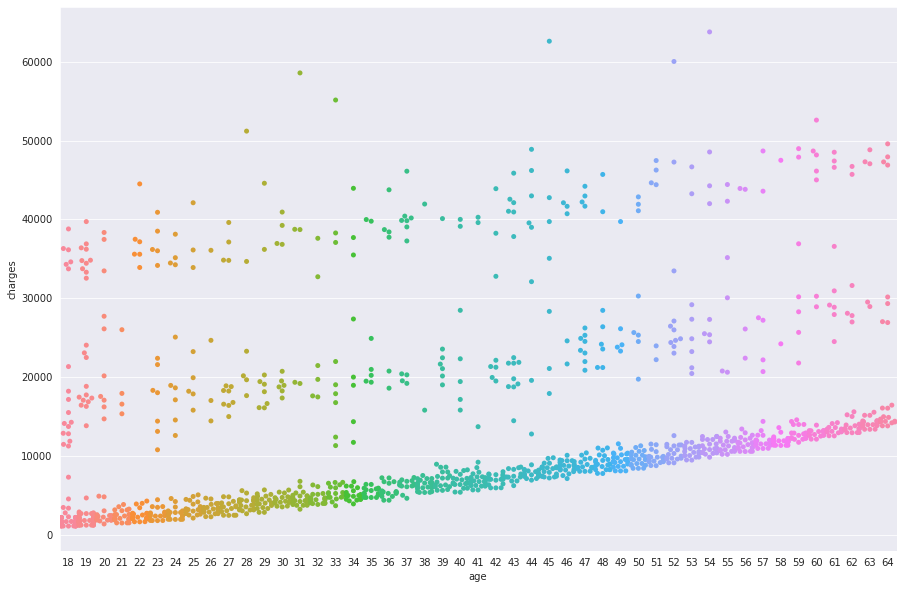

In [ ]:
age_bmi_Scatterplot = plt.figure(figsize=(15, 10))
sns.set_style('darkgrid')

sns.swarmplot(x = 'age', y = 'charges', data = insurance_df)
plt.show()

## 노이즈 데이터 제거

In [ ]:
train_df = insurance_df

In [ ]:
train_df.drop('sex', axis=1 ,inplace=True)
train_df.head()

,age,bmi,children,smoker,region,charges
0,19,27.900,0,yes,southwest,16884.92400
1,18,33.770,1,no,southeast,1725.55230
2,28,33.000,3,no,southeast,4449.46200
3,33,22.705,0,no,northwest,21984.47061
4,32,28.880,0,no,northwest,3866.85520


In [ ]:
train_input, test_input, train_target, test_target = train_test_split(insurance_df['age'], insurance_df['charges'], random_state = 200)

In [ ]:
lr = LinearRegression()

train_input = train_input.to_numpy()
test_input = test_input.to_numpy()
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)
print(len(train_input), len(train_target))
lr.fit(train_input, train_target)
print(lr.predict([[100]]))

1003 1003
[29514.6221377]


In [ ]:
print(lr.coef_, lr.intercept_)

[269.59304628] 2555.3175097136846


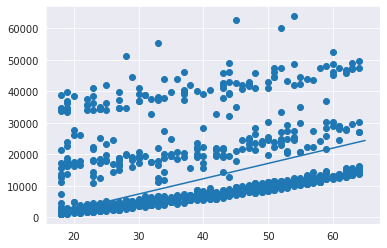

In [ ]:
plt.scatter(train_input, train_target)

plt.plot([20, 65], [0*lr.coef_ + lr.intercept_, 100*lr.coef_ - lr.intercept_])

plt.show()